In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from termcolor import colored

## Import des données

In [2]:
df = pd.read_parquet("data/votes.parquet")
df.head()

,id,timestamp,model_a_name,model_b_name,model_pair_name,chosen_model_name,opening_msg,both_equal,conversation_a,conversation_b,...,conv_incorrect_a,conv_incorrect_b,conv_superficial_a,conv_superficial_b,conv_instructions_not_followed_a,conv_instructions_not_followed_b,system_prompt_b,system_prompt_a,conv_complete_a,conv_complete_b
0,112580,2025-10-28 17:02:44.266579,gemini-2.5-flash,grok-4-fast,"[gemini-2.5-flash, grok-4-fast]",NaN,crée des cartes types dixit sur le thème des m...,True,[{'content': 'crée des cartes types dixit sur ...,[{'content': 'crée des cartes types dixit sur ...,...,False,False,False,False,False,False,NaN,NaN,False,False
1,55251,2025-04-22 18:07:44.914551,gemma-3-4b,c4ai-command-r-08-2024,"[c4ai-command-r-08-2024, gemma-3-4b]",gemma-3-4b,J'ai lu quelque part (je ne sais pas où) qu'ut...,False,[{'content': 'J'ai lu quelque part (je ne sais...,[{'content': 'J'ai lu quelque part (je ne sais...,...,False,False,False,True,False,False,NaN,NaN,True,False
2,56377,2025-04-28 08:47:19.683661,phi-4,llama-3.1-405b,"[llama-3.1-405b, phi-4]",NaN,créer un texte sur le degrés d'intégration des...,True,[{'content': 'créer un texte sur le degrés d'i...,[{'content': 'créer un texte sur le degrés d'i...,...,False,False,False,False,False,False,NaN,NaN,False,False
3,64275,2025-05-17 05:45:36.035179,phi-4,gemma-3-27b,"[gemma-3-27b, phi-4]",gemma-3-27b,Coucou,False,"[{'content': 'Coucou ', 'metadata': None, 'rea...","[{'content': 'Coucou ', 'metadata': None, 'rea...",...,False,False,False,False,False,False,NaN,NaN,False,False
4,30173,2025-02-24 15:05:34.404003,chocolatine-2-14b-instruct-v2.0.3-q8,gpt-4o-2024-08-06,"[chocolatine-2-14b-instruct-v2.0.3-q8, gpt-4o-...",gpt-4o-2024-08-06,Je souhaite élaborer des routines qui me perme...,False,[{'content': 'Tu es un assistant IA serviable ...,[{'content': 'Je souhaite élaborer des routine...,...,False,False,False,False,False,False,,Tu es un assistant IA serviable et bienveillan...,False,False


## Classement global

In [3]:
# Construction de la matrice de comparaison
df_filtered = df[df["both_equal"] == False]
print(f"Nombre de votes restants après filtrage `both_equal`: {len(df_filtered)}/{len(df)} ({100*len(df_filtered)/len(df):.2f}%)")
df_filtered[["model_a_name", "model_b_name"]].head()

Nombre de votes restants après filtrage `both_equal`: 94939/157132 (60.42%)


,model_a_name,model_b_name
1,gemma-3-4b,c4ai-command-r-08-2024
3,phi-4,gemma-3-27b
4,chocolatine-2-14b-instruct-v2.0.3-q8,gpt-4o-2024-08-06
5,llama-3.3-70b,llama-4-scout
6,grok-3-mini-beta,qwen3-32b


Top 10 des modèles les plus présents après filtrage `both_equal`:
model_a_name
llama-3.3-70b                 5232
gemma-3-4b                    5206
phi-4                         4842
gemma-3-27b                   4720
gemma-3-12b                   4627
gemini-2.0-flash              4595
mistral-large-2411            4332
llama-3.1-8b                  4328
command-a                     4042
ministral-8b-instruct-2410    4022
Name: count, dtype: int64


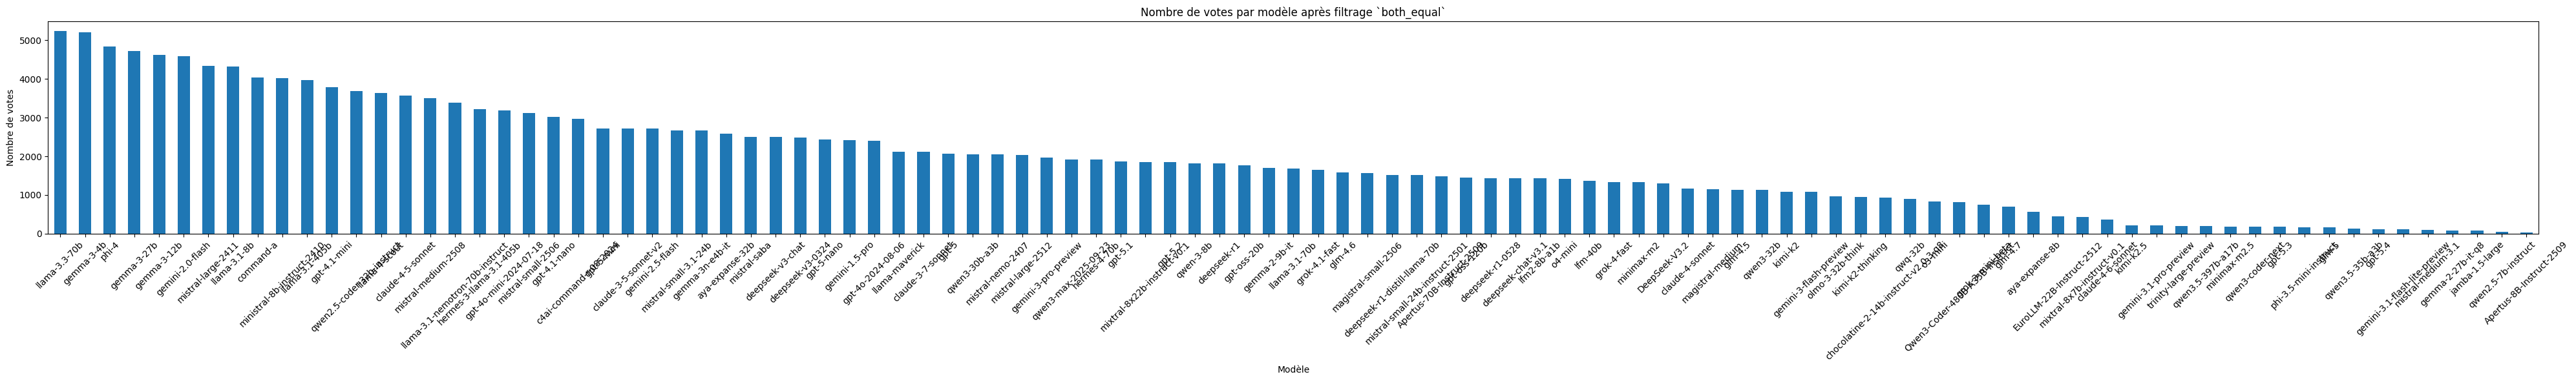

count     101.000000
mean     1879.980198
std      1363.203968
min        34.000000
25%       902.000000
50%      1687.000000
75%      2662.000000
max      5232.000000
Name: count, dtype: float64

In [4]:
def get_occurences_model(df:pd.DataFrame) -> pd.Series:
    """Récupère les modèles et leur nombre d'occurrences dans les colonnes `model_a_name` et `model_b_name`."""
    model_names_a = df["model_a_name"].value_counts()
    model_names_b = df["model_b_name"].value_counts()

    # Mise en commun des deux séries
    return model_names_a.add(model_names_b, fill_value=0).sort_values(ascending=False)

model_names = get_occurences_model(df_filtered)
print("Top 10 des modèles les plus présents après filtrage `both_equal`:")
print(model_names.head(10))

# Affichage de l'histogramme
fig = plt.figure(figsize=(40, 6))
model_names.plot(kind="bar")
plt.title("Nombre de votes par modèle après filtrage `both_equal`")
plt.xlabel("Modèle")
plt.ylabel("Nombre de votes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Détail
model_names.describe()

In [5]:
def build_ranking(model_names:list[str], df:pd.DataFrame) -> np.ndarray:
    """
    Construit la matrice de gain où W[i, j] est le nombre de fois que le modèle i a été préféré au modèle j dans les votes.
    """
    gains = np.zeros((len(model_names), len(model_names)), dtype=int)
    for row in df.itertuples():
        if row.model_a_name in model_names and row.model_b_name in model_names:
            i = model_names.index(row.model_a_name)
            j = model_names.index(row.model_b_name)
            if i == j:
                continue
            if row.chosen_model_name == row.model_a_name:
                gains[i, j] += 1
            elif row.chosen_model_name == row.model_b_name:
                gains[j, i] += 1
    return gains

In [6]:
def build_creative_ranking(model_names:list[str], df:pd.DataFrame) -> np.ndarray:
    """
    Construit la matrice de gain où W[i, j] est le nombre de fois que le modèle i a été préféré au modèle j dans les votes créatifs.
    """
    gains = np.zeros((len(model_names), len(model_names)), dtype=int)
    for row in df.itertuples():
        if row.conv_creative_a or row.conv_creative_b:
            if row.model_a_name in model_names and row.model_b_name in model_names:
                i = model_names.index(row.model_a_name)
                j = model_names.index(row.model_b_name)
                if row.conv_creative_a and not row.conv_creative_b:
                    gains[i, j] += 1
                elif row.conv_creative_b and not row.conv_creative_a:
                    gains[j, i] += 1
    return gains

### Recherche du nombre de modèles $N$ optimal

In [7]:
# Choix du nombre minimum d'occurence du modèle pour être inclus dans l'analyse
n_grid_search = np.arange(0, 1501, 250)

results = {}
for n in tqdm(n_grid_search, desc="Grid search on n"):
    eligible = model_names[model_names >= n].index
    sub = df_filtered[
        df_filtered["model_a_name"].isin(eligible) & df_filtered["model_b_name"].isin(eligible)
    ]
    sub_creative = sub[sub["conv_creative_a"] ^ sub["conv_creative_b"]]

    model_counts = get_occurences_model(sub)
    model_counts_creative = get_occurences_model(sub_creative)

    gains = build_ranking(list(eligible), sub)
    gains_creative = build_creative_ranking(list(eligible), sub)

    nb_duels = (gains+gains.T) / 2
    nb_duels_creative = (gains_creative+gains_creative.T) / 2

    triu = np.triu(np.ones((len(eligible), len(eligible))), k=1)
    triu_creative = np.triu(np.ones((len(eligible), len(eligible))), k=1)

    duels = nb_duels[triu == 1].flatten()
    duels_creative = nb_duels_creative[triu_creative == 1].flatten()

    results[n] = {"global":{
        "n_votes": len(sub),
        "n_models": len(model_counts),
        "min_votes_per_model": model_counts.min(),
        "max_votes_per_model": model_counts.max(),
        "mean_votes_per_model": model_counts.mean(),
        "ratio_pairs_with_duels": np.sum(duels > 0) / len(duels)
    }, "creative":{
        "n_votes": len(sub_creative),
        "n_models": len(model_counts_creative),
        "min_votes_per_model": model_counts_creative.min(),
        "max_votes_per_model": model_counts_creative.max(),
        "mean_votes_per_model": model_counts_creative.mean(),
        "ratio_pairs_with_duels": np.sum(duels_creative > 0) / len(duels_creative)
    }}

Grid search on n:   0%|          | 0/7 [00:00<?, ?it/s]

Grid search on n: 100%|██████████| 7/7 [00:15<00:00,  2.17s/it]


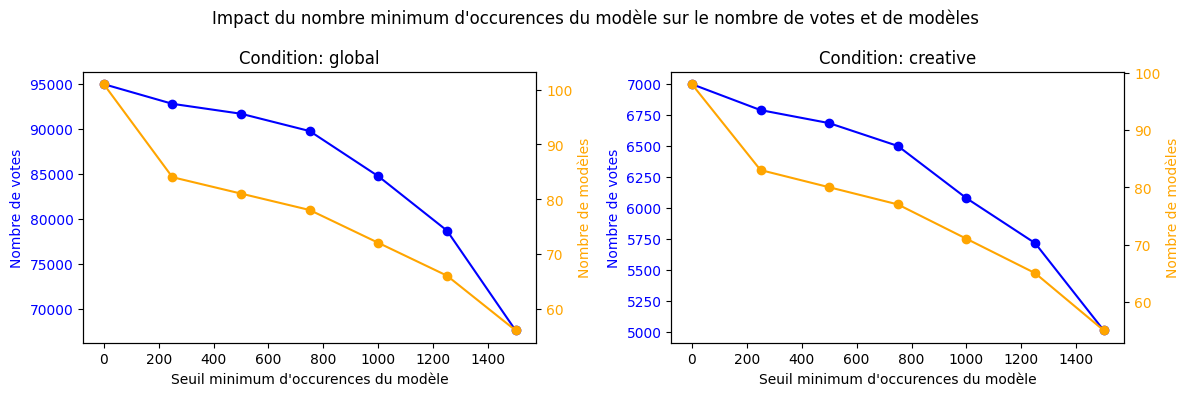

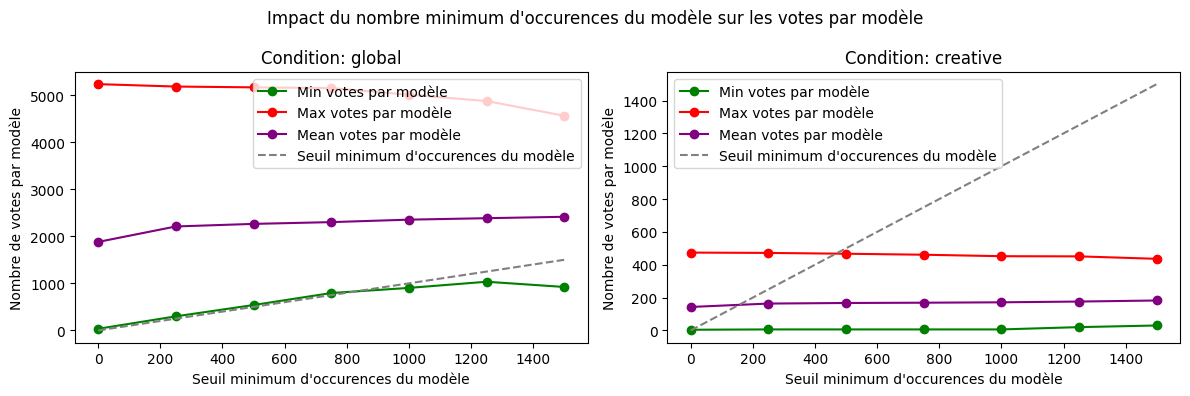

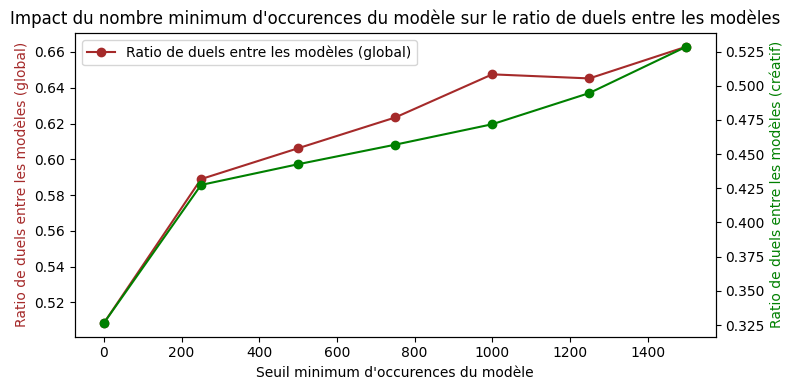

In [8]:
# Nombre de votes et de modèles en fonction du seuil minimum d'occurences du modèle
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Impact du nombre minimum d'occurences du modèle sur le nombre de votes et de modèles")
for i, condition in enumerate(["global", "creative"]):
    ax1 = axs[i]
    ax2 = ax1.twinx()
    ax1.plot(n_grid_search, [results[n][condition]["n_votes"] for n in n_grid_search], color="blue", marker="o", label="Nombre de votes")
    ax2.plot(n_grid_search, [results[n][condition]["n_models"] for n in n_grid_search], color="orange", marker="o", label="Nombre de modèles")
    ax1.set_xlabel("Seuil minimum d'occurences du modèle")
    ax1.set_ylabel("Nombre de votes", color="blue")
    ax2.set_ylabel("Nombre de modèles", color="orange")
    ax1.tick_params(axis="y", labelcolor="blue")
    ax2.tick_params(axis="y", labelcolor="orange")
    ax1.set_title(f"Condition: {condition}")
fig.tight_layout()
plt.show()

# Nombre d'occurrence min, max et mean par modèle en fonction du seuil minimum d'occurences du modèle
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Impact du nombre minimum d'occurences du modèle sur les votes par modèle")
for i, condition in enumerate(["global", "creative"]):
    ax = axs[i]
    ax.plot(n_grid_search, [results[n][condition]["min_votes_per_model"] for n in n_grid_search], color="green", marker="o", label="Min votes par modèle")
    ax.plot(n_grid_search, [results[n][condition]["max_votes_per_model"] for n in n_grid_search], color="red", marker="o", label="Max votes par modèle")
    ax.plot(n_grid_search, [results[n][condition]["mean_votes_per_model"] for n in n_grid_search], color="purple", marker="o", label="Mean votes par modèle")
    ax.plot(n_grid_search, n_grid_search, color="gray", linestyle="--", label="Seuil minimum d'occurences du modèle")
    ax.set_xlabel("Seuil minimum d'occurences du modèle")
    ax.set_ylabel("Nombre de votes par modèle")
    ax.set_title(f"Condition: {condition}")
    ax.legend()
fig.tight_layout()
plt.show()

# Ratio de duels entre les modèles en fonction du seuil minimum d'occurences du modèle
fig, ax = plt.subplots(figsize=(8, 4))
ax2 = ax.twinx()
ax.plot(n_grid_search, [results[n]["global"]["ratio_pairs_with_duels"] for n in n_grid_search], color="brown", marker="o", label="Ratio de duels entre les modèles (global)")
ax2.plot(n_grid_search, [results[n]["creative"]["ratio_pairs_with_duels"] for n in n_grid_search], color="green", marker="o", label="Ratio de duels entre les modèles (créatif)")
ax.set_xlabel("Seuil minimum d'occurences du modèle")
ax.set_ylabel("Ratio de duels entre les modèles (global)", color="brown")
ax2.set_ylabel("Ratio de duels entre les modèles (créatif)", color="green")
ax.set_title("Impact du nombre minimum d'occurences du modèle sur le ratio de duels entre les modèles")
ax.legend()
fig.tight_layout()
plt.show()

### Calcul de la matrice de gains et du classement

In [7]:
# On peut fixer jusqu'à N=2000 le nombre minimum d'occurence dans le dataset pour être inclus dans l'analyse
models = list(model_names.index)
kept_models = list(model_names[model_names >= 2000].index)
kept_models_idx = [models.index(m) for m in kept_models]
print(f"Nombre final de modèles retenus pour l'analyse: {len(kept_models)}")

Nombre final de modèles retenus pour l'analyse: 40


In [8]:
gains = build_ranking(models, df_filtered)
gains

array([[  0,  80, 127, ...,   2,   0,   0],
       [146,   0,  98, ...,   0,   0,   1],
       [ 83,  58,   0, ...,   4,   0,   0],
       ...,
       [  0,   0,   1, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], shape=(101, 101))

In [11]:
from bradley_terry import print_ranking, bootstrap_bradley_terry, estimate_bradley_terry
from itertools import product

beta, ranking = estimate_bradley_terry(gains)
print([models[i] for i in ranking[:15] if i in kept_models_idx])

['mistral-large-2512', 'mistral-medium-2508', 'gemini-2.5-flash', 'gemini-2.0-flash', 'deepseek-v3-0324', 'gemma-3-27b']


In [ ]:
duels = []
for i, j in product(range(len(models)), repeat=2):
    for _ in range(gains[i, j]):
        duels.append((i, j, 1))
duels = np.array(duels)

# Bootstrap avec détection automatique du B optimal
result_global = bootstrap_bradley_terry(
    duels,
    k=len(models),
    B=200,
    alpha=0.05,
    convergence_check=True,
    conv_window=100,
    conv_tol=0.005,
    kept_models_idx=kept_models_idx
)

print_ranking(result_global, models)

Bootstrap Bradley-Terry: 100%|██████████| 200/200 [00:21<00:00,  9.52réplique/s]


Rang  Modèle               log beta              IC 95 %  SE    
─────────────────────────────────────────────────────────────────
1     mistral-large-2512   +0.794   [+0.685, +0.889]  0.0516
2     mistral-medium-2508  +0.776   [+0.693, +0.844]  0.0386
3     gemini-2.5-flash     +0.730   [+0.626, +0.805]  0.0453
4     gemini-2.0-flash     +0.524   [+0.453, +0.605]  0.0385
5     deepseek-v3-0324     +0.449   [+0.356, +0.527]  0.0448
6     gemma-3-27b          +0.435   [+0.371, +0.493]  0.0331
7     deepseek-v3-chat     +0.361   [+0.276, +0.456]  0.0476
8     claude-4-5-sonnet    +0.351   [+0.279, +0.412]  0.0355
9     gemma-3-12b          +0.271   [+0.204, +0.343]  0.0348
10    mistral-small-2506   +0.251   [+0.176, +0.323]  0.0396
11    command-a            +0.160   [+0.069, +0.222]  0.0384
12    claude-3-7-sonnet    +0.159   [+0.061, +0.225]  0.0462
13    gemma-3n-e4b-it      +0.100   [+0.016, +0.179]  0.0446
14    gemma-3-4b           +0.082   [+0.006, +0.137]  0.0317
15    llama-3.

/tmp/ipykernel_740332/2938410927.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_models[:show_first], rotation=20, ha="right")


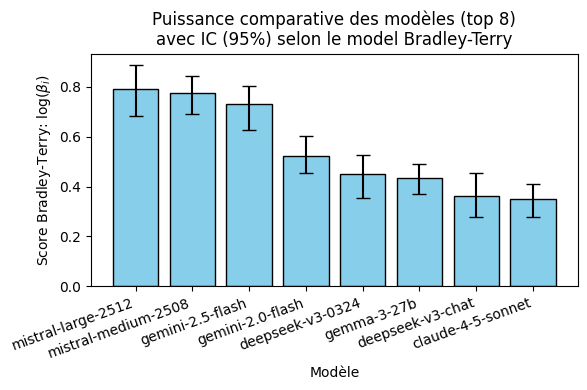

In [ ]:
def plot_top_models(result, models, show_first=5, show_error_bars=True):
    log_beta = result.log_beta
    sorted_indices = np.argsort(-log_beta)
    log_beta_sorted = log_beta[sorted_indices]
    y_err = np.array([result.log_beta - result.ci_low, result.ci_high - result.log_beta])[:, sorted_indices]
    sorted_models = np.array(models)[sorted_indices]

    fig, ax = plt.subplots(figsize=(6, 4))
    if show_error_bars:
        ax.bar(sorted_models[:show_first], log_beta_sorted[:show_first], yerr=y_err[:, :show_first], capsize=5, color="skyblue", edgecolor="black")
    else:
        ax.bar(sorted_models[:show_first], log_beta_sorted[:show_first], color="skyblue", edgecolor="black")
    ax.set_xlabel("Modèle")
    ax.set_ylabel(r"Score Bradley-Terry: $\log(\beta_i)$")
    ax.set_title(f"Puissance comparative des modèles (top {show_first})\navec IC (95%) selon le model Bradley-Terry")
    ax.set_xticklabels(sorted_models[:show_first], rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

plot_top_models(result_global, kept_models, show_first=8)

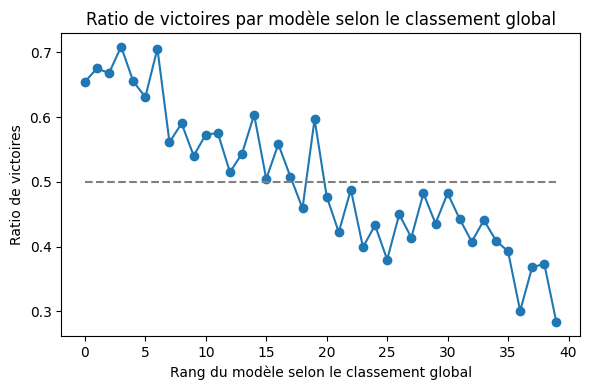

In [19]:
def plot_wins_by_ranking(gains:np.ndarray, ranking:np.ndarray, models:list[str], ranking_name:str):
    ratio_wins = (gains.sum(axis=1) / (gains.sum(axis=1) + gains.sum(axis=0)))[ranking]
    plt.figure(figsize=(6, 4))
    plt.plot(range(len(models)), ratio_wins, marker="o", linestyle="-")
    plt.plot([0, len(models)-1], [0.5, 0.5], color="gray", linestyle="--")
    plt.xlabel(f"Rang du modèle selon le {ranking_name}")
    plt.ylabel("Ratio de victoires")
    plt.title(f"Ratio de victoires par modèle selon le {ranking_name}")
    # plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

ranking_global = np.argsort(-result_global.log_beta)
plot_wins_by_ranking(gains, ranking_global, kept_models, ranking_name="classement global")

## Classement de la créativité

In [20]:
df_crea_filtered = df[df[["conv_creative_a", "conv_creative_b"]].any(axis=1)]
print(f"Nombre de votes restants après filtrage `creative`: {len(df_crea_filtered)}/{len(df)} ({100*len(df_crea_filtered)/len(df):.2f}%)")

Nombre de votes restants après filtrage `creative`: 11069/157132 (7.04%)


In [21]:
creative_gains = build_creative_ranking(models, df_crea_filtered)
creative_gains

array([[ 0,  1,  9, ...,  0,  0,  0],
       [15,  0,  9, ...,  0,  0,  0],
       [ 5,  3,  1, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], shape=(101, 101))

In [22]:
duels = []
for i, j in product(range(len(models)), repeat=2):
    for _ in range(creative_gains[i, j]):
        duels.append((i, j, 1))
duels = np.array(duels)

# Bootstrap avec détection automatique du B optimal
result_creative = bootstrap_bradley_terry(
    duels,
    k=len(models),
    B=1000,
    alpha=0.05,
    convergence_check=True,
    conv_window=100,
    conv_tol=0.005,
    kept_models_idx=kept_models_idx
)

print_ranking(result_creative, models)

/home/alexandre/Documents/CS/3A/Mention IA/Étude de cas/compar-ia/bradley_terry.py:41: RuntimeWarning: invalid value encountered in divide
  beta = np.where(W_wins > 0, W_wins / denom, 1e-10)
Bootstrap Bradley-Terry: 100%|██████████| 1000/1000 [01:42<00:00,  9.71réplique/s]


Rang  Modèle               log beta              IC 95 %  SE    
─────────────────────────────────────────────────────────────────
1     mistral-medium-2508  +0.909   [-4.356, +1.175]  2.0317
2     mistral-large-2512   +0.692   [-4.581, +0.908]  2.0201
3     gemini-2.5-flash     +0.521   [-4.761, +0.807]  2.0353
4     gemma-3n-e4b-it      +0.333   [-4.992, +0.567]  2.0260
5     gemma-3-27b          +0.298   [-5.000, +0.441]  2.0293
6     gemini-2.0-flash     +0.277   [-5.053, +0.450]  2.0357
7     claude-4-5-sonnet    +0.265   [-5.046, +0.464]  2.0188
8     deepseek-v3-0324     +0.134   [-5.163, +0.327]  2.0235
9     mistral-small-2506   +0.109   [-5.201, +0.317]  2.0222
10    gemma-3-12b          +0.083   [-5.197, +0.227]  2.0285
11    gemma-3-4b           +0.077   [-5.191, +0.223]  2.0241
12    llama-3.1-nemotron-70b-instruct +0.032   [-5.302, +0.239]  2.0277
13    gpt-5-nano           -0.069   [-5.384, +0.262]  2.0405
14    qwen3-30b-a3b        -0.090   [-5.474, +0.244]  2.0348
15 

/tmp/ipykernel_740332/2938410927.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_models[:show_first], rotation=20, ha="right")


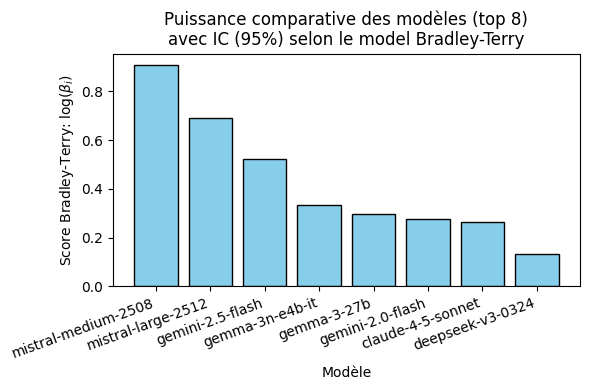

In [24]:
plot_top_models(result_creative, models, show_first=8, show_error_bars=False)

/tmp/ipykernel_740332/4227486848.py:2: RuntimeWarning: invalid value encountered in divide
  ratio_wins = (gains.sum(axis=1) / (gains.sum(axis=1) + gains.sum(axis=0)))[ranking]


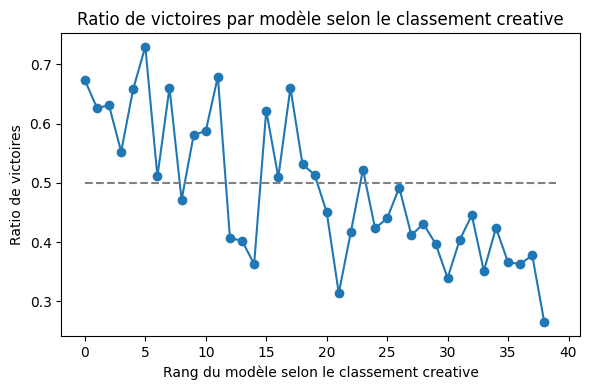

In [26]:
ranking_creative = np.argsort(-result_creative.log_beta)
plot_wins_by_ranking(creative_gains, ranking_creative, kept_models, ranking_name="classement creative")

## Différence entre les classements

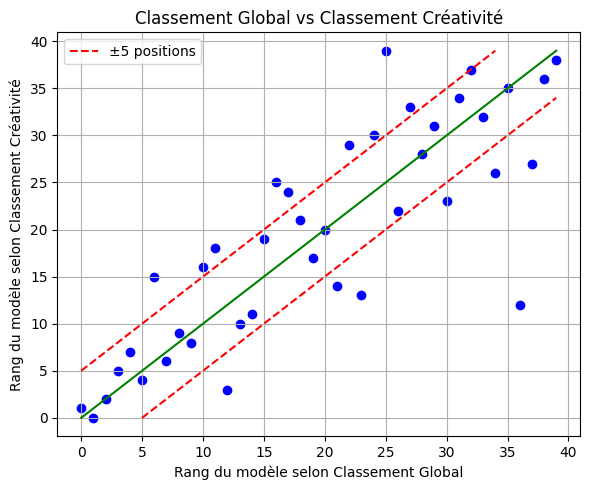

Coefficient de Spearman : 0.835
P-value : 2.09E-11

Top 10 des pires changements de rangs :
gpt-5-nano : Classement Global = 36, Classement Créativité = 12, Différence = 24
gpt-5 : Classement Global = 25, Classement Créativité = 39, Différence = 14
c4ai-command-r-08-2024 : Classement Global = 37, Classement Créativité = 27, Différence = 10
qwen3-30b-a3b : Classement Global = 23, Classement Créativité = 13, Différence = 10
deepseek-v3-chat : Classement Global = 6, Classement Créativité = 15, Différence = 9
gemma-3n-e4b-it : Classement Global = 12, Classement Créativité = 3, Différence = 9
mistral-large-2411 : Classement Global = 16, Classement Créativité = 25, Différence = 9
llama-3.1-405b : Classement Global = 34, Classement Créativité = 26, Différence = 8
claude-3-5-sonnet-v2 : Classement Global = 30, Classement Créativité = 23, Différence = 7
mistral-saba : Classement Global = 17, Classement Créativité = 24, Différence = 7


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def compare_rankings(ranking1, ranking2, models, title1="Classement 1", title2="Classement 2"):
    """
    Compare deux classements en calculant leur corrélation de Spearman
    et en affichant une visualisation côte à côte.

    Args:
        ranking1 (np.ndarray): Premier classement (indices des modèles).
        ranking2 (np.ndarray): Deuxième classement (indices des modèles).
        title1 (str): Titre du premier classement.
        title2 (str): Titre du deuxième classement.
    """
    ranks_1_by_model = np.argsort(ranking1)
    ranks_2_by_model = np.argsort(ranking2)

    # Calcul du coefficient de corrélation de Spearman
    spearman_corr, p_value = spearmanr(ranks_1_by_model, ranks_2_by_model)

    # Visualisation des classements
    plt.figure(figsize=(6, 5))

    # Classement 1 en fonction du classement 2
    plt.scatter(ranks_1_by_model, ranks_2_by_model, color='blue')
    plt.plot([0, len(models)-1], [0, len(models)-1], color='green')
    plt.plot([5, len(models)-1], [0, len(models)-6], color='red', linestyle='--')
    plt.plot([0, len(models)-6], [5, len(models)-1], color='red', linestyle='--', label="±5 positions")
    plt.title(f"{title1} vs {title2}")
    plt.xlabel(f"Rang du modèle selon {title1}")
    plt.ylabel(f"Rang du modèle selon {title2}")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Affichage du résultat
    print(f"Coefficient de Spearman : {spearman_corr:.3f}")
    print(f"P-value : {p_value:.2E}")

    # Top 5 des pires changement de rangs
    rank_diff = np.abs(ranks_1_by_model - ranks_2_by_model)
    worst_changes = np.argsort(rank_diff)[-10:]
    print("\nTop 10 des pires changements de rangs :")
    for idx in worst_changes[::-1]:
        print(f"{colored(models[idx], "red")} : {title1} = {ranks_1_by_model[idx]}, {title2} = {ranks_2_by_model[idx]}, {colored("Différence", "blue")} = {rank_diff[idx]}")

compare_rankings(ranking_global, ranking_creative, kept_models, "Classement Global", "Classement Créativité")

On observe un coefficient de Spearman de 0.019 ce qui illustre une faible corrélation entre les deux classements.

Parmi les raisons de cette faible corrélation, certains modèles ont des performances très différentes sur les deux classements :
- Bon globalement mais pas créatif : gpt-5, deepseek-v3-chat, mistral-large-2411
- Créatif mais moins bon globalement : gpt-5-nano, c4ai-command-r-08-2024, qwen3-30b-a3b